In [1]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q transformers opencv-python pillow pandas scikit-learn editdistance tqdm

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU Device: NVIDIA H100 80GB HBM3
GPU Memory: 85.02 GB


In [2]:
import os
import sys
import shutil
from pathlib import Path

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from transformers import ViTModel, GPT2LMHeadModel, AutoImageProcessor

# Set random seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Environment: Kaggle
Dataset Directory: /kaggle/input/datasets/saon110/bangla-handwritten-datatset/dataset
Output Directory: /kaggle/working
Images found: 547941
Labels loaded: 547941 samples

First 3 samples:
         image_id     text
0  word_00000.jpg     কথা 
1  word_00001.jpg  প্রকাশ 
2  word_00002.jpg   ছড়িয়ে 


/tmp/ipykernel_44/2650813408.py:59: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_44/2650813408.py:59: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_44/2650813408.py:59: UserWarning: Glyph 2469 (\N{BENGALI LETTER THA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_44/2650813408.py:59: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_44/2650813408.py:59: UserWarning: Glyph 2447 (\N{BENGALI LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_44/2650813408.py:59: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_44/2650813408.py:59: UserWarning: Glyph 2434 (\N{BENGALI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_44/2650813408.py:

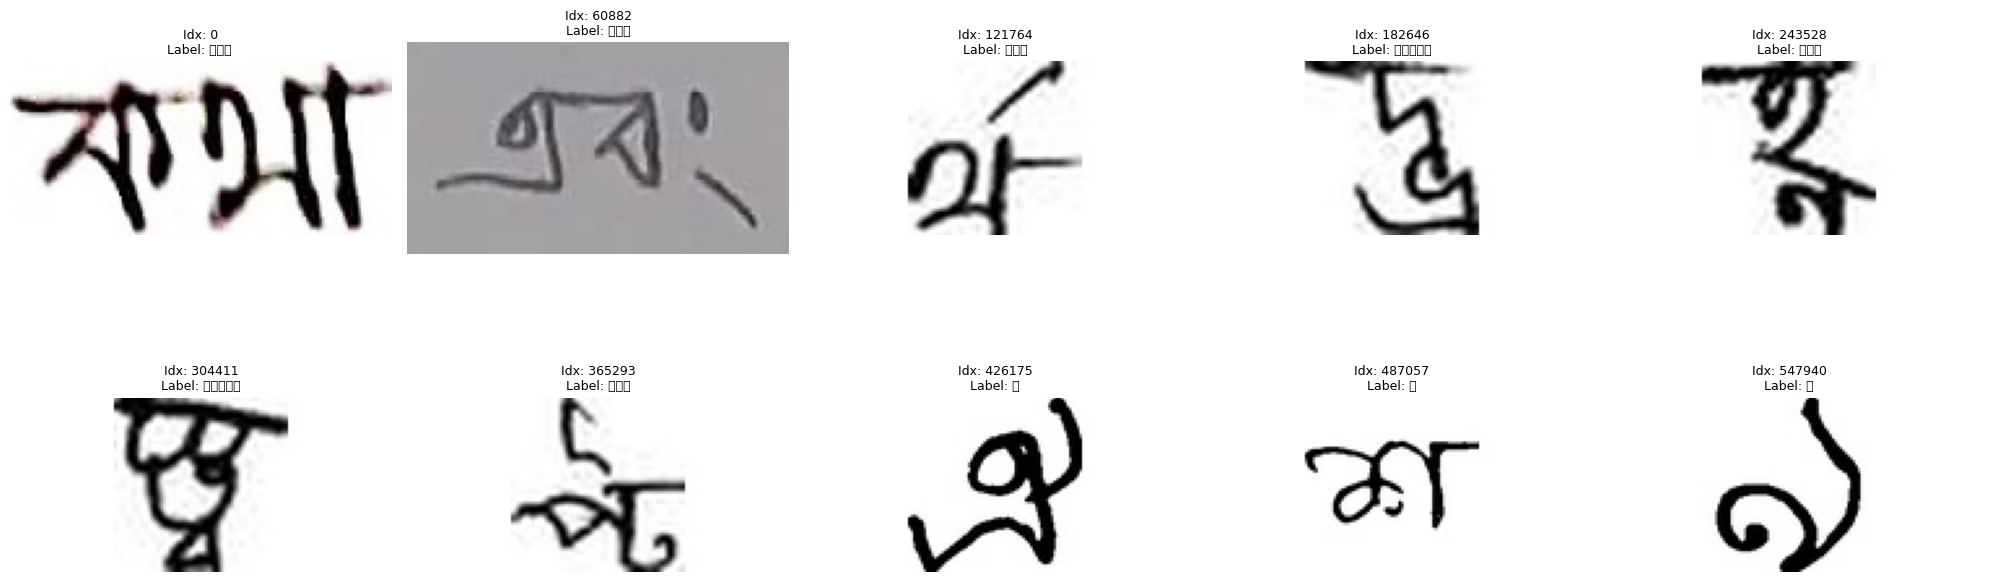

In [3]:
# ========================================
# 3. Configure Paths (Kaggle Only)
# ========================================

BASE_PATH = '/kaggle/input/datasets/mahmud1628/graphemes'
DATASET_DIR = "/kaggle/input/datasets/saon110/bangla-handwritten-datatset/dataset"  # expects DATASET_DIR/images and DATASET_DIR/labels/label.csv
OUTPUT_DIR = '/kaggle/working'

sys.path.insert(0, BASE_PATH)
sys.path.insert(0, os.path.join(BASE_PATH, 'BnGraphemizer'))

# Create checkpoint directory for new run outputs
NEW_CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints')
os.makedirs(NEW_CHECKPOINT_DIR, exist_ok=True)

# Verify dataset exists (no dataset creation step required)
images_dir = os.path.join(DATASET_DIR, 'images')
labels_file = os.path.join(DATASET_DIR, 'labels', 'label.csv')

if not os.path.exists(images_dir) or not os.path.exists(labels_file):
    raise FileNotFoundError(f"Dataset not found. Expected images and labels/label.csv under: {DATASET_DIR}")

print("Environment: Kaggle")
print(f"Dataset Directory: {DATASET_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"Images found: {len(os.listdir(images_dir))}")

# Read and verify dataset
df = pd.read_csv(labels_file)
print(f"Labels loaded: {len(df)} samples")
print("\nFirst 3 samples:")
print(df.head(3))

# Show 10 evenly spaced images and labels from the dataset
num_preview = min(10, len(df))
preview_indices = np.linspace(0, len(df) - 1, num_preview, dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for plot_idx, data_idx in enumerate(preview_indices):
    row = df.iloc[data_idx]
    image_name = str(row['image_id'])
    label_text = str(row['text'])
    image_path = os.path.join(images_dir, image_name)

    if os.path.exists(image_path):
        img = Image.open(image_path).convert('RGB')
        axes[plot_idx].imshow(img)
    else:
        axes[plot_idx].text(0.5, 0.5, 'Image not found', ha='center', va='center', fontsize=10)

    axes[plot_idx].set_title(f"Idx: {data_idx}\nLabel: {label_text}", fontsize=9)
    axes[plot_idx].axis('off')

# Hide any extra axes if dataset has fewer than 10 samples
for i in range(num_preview, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
class TrieTokenizer:
    def __init__(self, vocab, separator=""):
        self.vocab = vocab
        self.separator = separator
        self.trie = self._make_trie()
        
    def _make_trie(self):
        trie = {}
        for token in self.vocab:
            self._add_token(trie, token)
        return trie
    
    def _add_token(self, trie, token):
        node = trie
        for char in token:
            if char not in node:
                node[char] = {}
            node = node[char]
        node[''] = token
    
    def tokenize(self, text):
        tokens = []
        i = 0
        while i < len(text):
            token, length = self._get_next_token(text, i)
            if token:
                tokens.append(token)
                i += length
            else:
                i += 1
        return tokens
    
    def _get_next_token(self, text, start):
        node = self.trie
        last_token = None
        last_length = 0
        
        for i, char in enumerate(text[start:]):
            if char not in node:
                break
            node = node[char]
            if '' in node:
                last_token = node['']
                last_length = i + 1
        
        return last_token, last_length

print("✓ TrieTokenizer defined")

✓ TrieTokenizer defined


In [5]:
import unicodedata
from collections import defaultdict
from typing import Union, List

class GraphemeTokenizer:
    def __init__(self, tokenizer_class, max_len=64, separator="", blank_token="_", 
                 oov_token="▁", normalize_unicode=False, normalization_mode="NFKC",
                 normalizer="unicode", printer=print, bos_token="_", eos_token="_",
                 add_bos_token=True, add_eos_token=True):
        self.vocab = list(dict.fromkeys([oov_token, blank_token, bos_token, eos_token]))
        self.max_len = max_len
        self.oov_token = oov_token
        self.blank_token = blank_token
        self.bos_token = bos_token
        self.eos_token = eos_token
        self.add_bos_token = add_bos_token
        self.add_eos_token = add_eos_token
        self.tokenizer_class = tokenizer_class
        self.separator = separator
        self.tokenizer = self.tokenizer_class([(idx) for idx in self.vocab], separator=self.separator)
        self.word2index = {token: idx for idx, token in enumerate(self.vocab)}
        self.normalize_unicode = normalize_unicode
        self.normalization_mode = normalization_mode
        self.print = printer
        self.out_of_vocabulary_info = defaultdict(set)
        self.frequency_counter = defaultdict(int)
        self._set_normalizer(normalizer)
        self.pad_token_id = self.word2index[self.blank_token]
        self.bos_token_id = self.word2index[self.bos_token]
        self.eos_token_id = self.word2index[self.eos_token]

    def tokenize(self, text, padding=False, normalize_unicode=None, normalization_mode=None):
        if isinstance(text, list):
            return [self.tokenize(_text, padding, normalize_unicode, normalization_mode) for _text in text]
        
        normalize_unicode = self.normalize_unicode if normalize_unicode is None else normalize_unicode
        if normalize_unicode:
            text = self._unicode_normalizer(text, normalization_mode)
        
        tokens = self.tokenizer.tokenize(text)
        
        if self.add_bos_token and self.add_eos_token:
            tokens = [self.bos_token] + tokens + [self.eos_token]
        elif self.add_bos_token:
            tokens = [self.bos_token] + tokens
        elif self.add_eos_token:
            tokens = tokens + [self.eos_token]
        
        tokens = tokens[:self.max_len]
        n_tokens = len(tokens)
        
        if padding:
            tokens = tokens + [self.blank_token] * (self.max_len - n_tokens)
        
        tokens_id = [self.word2index.get(token, self.word2index[self.oov_token]) for token in tokens]
        attention_mask = [1] * n_tokens + [0] * (len(tokens) - n_tokens)
        
        return {'tokens': tokens, 'input_ids': tokens_id, 'token_len': n_tokens, 'attention_mask': attention_mask}

    def add_tokens(self, vocab, normalize_unicode=None, reset_oov=False):
        normalize_unicode = self.normalize_unicode if normalize_unicode is None else normalize_unicode
        vocab = self._validate_tokens(vocab, normalize_unicode)
        self.vocab = self.vocab + vocab
        self.tokenizer = self.tokenizer_class([(v) for v in self.vocab], separator=self.separator)
        self.word2index = {token: idx for idx, token in enumerate(self.vocab)}
        self.bos_token_id = self.word2index[self.bos_token]
        self.eos_token_id = self.word2index[self.eos_token]
        if reset_oov:
            self.reset_out_of_vocabulary_info(keys=vocab)

    def _validate_tokens(self, vocab, normalize_unicode=False):
        if normalize_unicode:
            vocab = list(map(self._unicode_normalizer, vocab))
        vocab = sorted(list(set(vocab)))
        vocab = [v for v in vocab if v not in self.vocab]
        return vocab

    def _set_normalizer(self, type="unicode"):
        if type == "unicode":
            self.normalizer = lambda text, mode: unicodedata.normalize(mode, text)
        else:
            self.normalizer = lambda text, mode: text

    def _unicode_normalizer(self, text, mode=None):
        mode = self.normalization_mode if mode is None else mode
        text = self.normalizer(text, mode)
        text = text.replace("\u200c", "").replace("\u200d", "")
        return text

    def ids_to_token(self, ids):
        if not ids:
            raise ValueError("ids must be non-empty")
        if not isinstance(ids[0], list):
            token_list = [self.vocab[idx] for idx in ids 
                         if self.vocab[idx] not in [self.blank_token, self.bos_token, self.eos_token]]
            return token_list
        if isinstance(ids[0], list):
            return list(map(self.ids_to_token, ids))

    def ids_to_text(self, ids):
        if not ids:
            raise ValueError("ids must be non-empty")
        tokens = self.ids_to_token(ids)
        if not isinstance(tokens[0], list):
            return "".join(tokens)
        if isinstance(tokens[0], list):
            return list(map("".join, tokens))

    def _get_index(self, text, token):
        index = self.word2index.get(token)
        self.frequency_counter[token] += 1
        if index is not None:
            return index
        self.out_of_vocabulary_info[token].add(text)
        return self.word2index[self.oov_token]

    def reset_out_of_vocabulary_info(self, keys=None):
        if isinstance(keys, list):
            for k in keys:
                self.out_of_vocabulary_info.pop(k, None)
            return
        if isinstance(keys, str):
            if keys.lower() == "all":
                self.out_of_vocabulary_info = defaultdict(set)
            return

print("✓ GraphemeTokenizer defined")

✓ GraphemeTokenizer defined


In [6]:
class BnGraphemizerProcessor:
    def __init__(self, grapheme_file, model_max_length=128, normalize_unicode=True,
                 normalization_mode='NFKC', normalizer="unicode", blank_token="_",
                 bos_token="<s>", eos_token="</s>", add_bos_token=True, add_eos_token=True):
        self.grapheme_file = grapheme_file
        self.model_max_length = model_max_length
        self.blank_token = blank_token
        self.bos_token = bos_token
        self.eos_token = eos_token
        self.list_of_graphemes = self._load_graphemes()
        self.bn_graphmemizer = self._initialize_graphemizer()
        self.pad_token_id = self.bn_graphmemizer.pad_token_id
        self.bos_token_id = self.bn_graphmemizer.bos_token_id
        self.eos_token_id = self.bn_graphmemizer.eos_token_id
        self.vocab = self.bn_graphmemizer.vocab

    def _load_graphemes(self):
        with open(self.grapheme_file, 'r', encoding='utf-8') as f:
            graphemes = sorted(list(set([line.rstrip('\n\r') for line in f.readlines() if line.strip()])))
        return graphemes

    def _initialize_graphemizer(self):
        graphemizer = GraphemeTokenizer(
            tokenizer_class=TrieTokenizer, max_len=self.model_max_length,
            blank_token=self.blank_token, bos_token=self.bos_token, eos_token=self.eos_token,
            add_bos_token=True, add_eos_token=True
        )
        graphemizer.add_tokens(self.list_of_graphemes, reset_oov=True)
        return graphemizer

    def __call__(self, texts, padding=False):
        bng_text_inputs = self.bn_graphmemizer.tokenize(texts, padding=padding)
        bng_inputs = self._get_tokenized_inputs(bng_text_inputs)
        bng_input_ids = torch.Tensor(bng_inputs['input_ids']).long()
        bng_attention_mask = torch.Tensor(bng_inputs['attention_mask']).long()
        if bng_input_ids.ndim == 1:
            bng_input_ids = bng_input_ids.unsqueeze(0)
        if bng_attention_mask.ndim == 1:
            bng_attention_mask = bng_attention_mask.unsqueeze(0)
        return {'input_ids': bng_input_ids, 'attention_mask': bng_attention_mask}

    def _get_tokenized_inputs(self, inputs):
        if not isinstance(inputs, list):
            return {'input_ids': inputs['input_ids'], 'attention_mask': inputs['attention_mask']}
        input_ids, attention_mask = [], []
        for input in inputs:
            if isinstance(input, list):
                input = self._get_tokenized_inputs(input)
            input_ids.append(input['input_ids'])
            attention_mask.append(input['attention_mask'])
        return {'input_ids': input_ids, 'attention_mask': attention_mask}

    def decode(self, input_ids):
        if isinstance(input_ids, torch.Tensor):
            input_ids = input_ids.cpu().numpy() if input_ids.is_cuda else input_ids.numpy()
        if isinstance(input_ids, np.ndarray):
            input_ids = input_ids.tolist()
        if isinstance(input_ids, list):
            if len(input_ids) == 0:
                return ""
            if isinstance(input_ids[0], list):
                return [self.decode(ids) for ids in input_ids]
            else:
                token_list = self.bn_graphmemizer.ids_to_token(input_ids)
                return ''.join(token_list)

print("✓ BnGraphemizerProcessor defined")

✓ BnGraphemizerProcessor defined


In [7]:
class ViTGPT2EncoderDecoder(nn.Module):
    def __init__(self, vocab_size, max_length=128):
        super().__init__()
        
        # Load pretrained ViT encoder
        self.encoder = ViTModel.from_pretrained('google/vit-base-patch16-224')
        
        # ✅ FIX: Create GPT-2 config with cross-attention FIRST
        from transformers import GPT2Config
        
        gpt2_config = GPT2Config.from_pretrained('openai-community/gpt2')
        gpt2_config.add_cross_attention = True
        gpt2_config.is_decoder = True
        
        # Create GPT-2 with cross-attention layers (original vocab size)
        self.decoder = GPT2LMHeadModel(gpt2_config)
        
        # Load pretrained weights (now vocab sizes match: 50257)
        pretrained_state = GPT2LMHeadModel.from_pretrained('openai-community/gpt2').state_dict()
        
        # Load all compatible weights (cross-attention will be missing, that's OK)
        missing_keys, unexpected_keys = self.decoder.load_state_dict(pretrained_state, strict=False)
        
        print(f"✓ Loaded GPT-2 pretrained weights")
        print(f"  Missing keys (cross-attention): {len([k for k in missing_keys if 'crossattention' in k])}")
        print(f"  Other missing keys: {len([k for k in missing_keys if 'crossattention' not in k])}")
        
        # ✅ NOW resize vocabulary to Bengali size AFTER loading weights
        self.decoder.resize_token_embeddings(vocab_size)
        print(f"✓ Resized vocabulary: 50257 → {vocab_size}")
        
        # Project ViT hidden states to GPT-2 hidden size
        vit_hidden_size = self.encoder.config.hidden_size  # 768
        gpt2_hidden_size = self.decoder.config.n_embd      # 768
        
        if vit_hidden_size != gpt2_hidden_size:
            self.encoder_projection = nn.Linear(vit_hidden_size, gpt2_hidden_size)
        else:
            self.encoder_projection = nn.Identity()
        
        self.vocab_size = vocab_size
        self.max_length = max_length
    
    def forward(self, pixel_values, input_ids, attention_mask=None, labels=None):
        # Encode image
        encoder_outputs = self.encoder(pixel_values=pixel_values)
        encoder_hidden_states = encoder_outputs.last_hidden_state
        encoder_hidden_states = self.encoder_projection(encoder_hidden_states)
        
        encoder_attention_mask = torch.ones(
            encoder_hidden_states.shape[:2], 
            dtype=torch.long, 
            device=encoder_hidden_states.device
        )
        
        # ✅ CHANGE: Add label smoothing
        if labels is not None:
            # Compute loss with label smoothing manually
            outputs = self.decoder(
                input_ids=input_ids,
                attention_mask=attention_mask,
                encoder_hidden_states=encoder_hidden_states,
                encoder_attention_mask=encoder_attention_mask,
                labels=None,  # Don't compute loss internally
                return_dict=True
            )
            
            # Label smoothing loss
            logits = outputs.logits
            loss_fct = nn.CrossEntropyLoss(
                ignore_index=-100, 
                label_smoothing=0.1  # Add smoothing
            )
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            loss = loss_fct(
                shift_logits.view(-1, shift_logits.size(-1)), 
                shift_labels.view(-1)
            )
        else:
            outputs = self.decoder(
                input_ids=input_ids,
                attention_mask=attention_mask,
                encoder_hidden_states=encoder_hidden_states,
                encoder_attention_mask=encoder_attention_mask,
                labels=labels,
                return_dict=True
            )
            loss = outputs.loss
        
        # Calculate accuracy
        accuracy = None
        if labels is not None:
            shift_logits = outputs.logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            predictions = torch.argmax(shift_logits, dim=-1)
            
            if attention_mask is not None:
                mask = attention_mask[..., 1:].reshape(-1)
                matches = (predictions.view(-1) == shift_labels.view(-1)).float()
                accuracy = (mask * matches).sum() / mask.sum()
            else:
                accuracy = (predictions == shift_labels).float().mean()
        
        return {
            'loss': loss,
            'logits': outputs.logits,
            'accuracy': accuracy
        }
    
    @torch.no_grad()
    def generate(self, pixel_values, max_length=128, num_beams=1, bos_token_id=1, eos_token_id=2, pad_token_id=0):
        # Encode image
        encoder_outputs = self.encoder(pixel_values=pixel_values)
        encoder_hidden_states = encoder_outputs.last_hidden_state
        encoder_hidden_states = self.encoder_projection(encoder_hidden_states)
        
        encoder_attention_mask = torch.ones(
            encoder_hidden_states.shape[:2],
            dtype=torch.long,
            device=encoder_hidden_states.device
        )
        
        # Generate with cross-attention
        batch_size = pixel_values.shape[0]
        input_ids = torch.full(
            (batch_size, 1), 
            bos_token_id, 
            dtype=torch.long, 
            device=pixel_values.device
        )
        
        generated = self.decoder.generate(
            input_ids=input_ids,
            encoder_hidden_states=encoder_hidden_states,
            encoder_attention_mask=encoder_attention_mask,
            max_length=max_length,
            num_beams=num_beams,
            eos_token_id=eos_token_id,
            pad_token_id=pad_token_id,
            early_stopping=True
        )
        
        return generated

print("✓ ViTGPT2EncoderDecoder model defined")

✓ ViTGPT2EncoderDecoder model defined


In [8]:
# ========================================
# 8. Dataset and DataLoader (MODIFIED)
# ========================================

# Initialize text processor
VOCAB_FILE = os.path.join(BASE_PATH, 'bn_grapheme_1296_from_bengali.ai.buet.txt')
text_processor = BnGraphemizerProcessor(VOCAB_FILE, model_max_length=128)
image_processor = AutoImageProcessor.from_pretrained(
    'google/vit-base-patch16-224',
    size={'height': 224, 'width': 224},
    use_fast=True
)

print(f"Vocabulary size: {len(text_processor.vocab)}")
print(f"PAD token ID: {text_processor.pad_token_id}")
print(f"BOS token ID: {text_processor.bos_token_id}")
print(f"EOS token ID: {text_processor.eos_token_id}")

# ========================================
# Dataset Class (Same as before)
# ========================================

class HandwrittenDataset(Dataset):
    def __init__(self, images_dir, data_frame, image_processor, text_processor):
        super().__init__()
        self.images_dir = images_dir
        self.df = data_frame
        self.image_processor = image_processor
        self.text_processor = text_processor
        self.image_ids = self.df["image_id"].values
        self.texts = self.df["text"].values
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        image = Image.open(os.path.join(self.images_dir, str(self.image_ids[index]))).convert('RGB')
        text = str(self.texts[index])
        
        image_inputs = self.image_processor(image, return_tensors="pt")
        pixel_values = image_inputs['pixel_values'][0]
        
        text_inputs = self.text_processor(text, padding=True)
        input_ids = text_inputs['input_ids'][0]
        attention_mask = text_inputs['attention_mask'][0]
        
        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': input_ids.clone()
        }

# ========================================
# Load Prepared Dataset
# ========================================

images_dir = os.path.join(DATASET_DIR, 'images')
labels_file = os.path.join(DATASET_DIR, 'labels', 'label.csv')
df = pd.read_csv(labels_file)

print(f"\n📊 Dataset Statistics:")
print(f"Total samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

# Split dataset (same random state for reproducibility)
train_df, val_df = train_test_split(df, test_size=0.15, random_state=42)
train_dataset = HandwrittenDataset(images_dir, train_df, image_processor, text_processor)
val_dataset = HandwrittenDataset(images_dir, val_df, image_processor, text_processor)

print(f"\n✅ Train samples: {len(train_dataset)}")
print(f"✅ Val samples: {len(val_dataset)}")

# ========================================
# H100 Optimized DataLoaders
# ========================================

BATCH_SIZE = 16  # ✅ Increased for H100 (was 8 for 2xT4)
NUM_WORKERS = 4   # ✅ H100 can handle more parallel loading

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,
    persistent_workers=True  # ✅ Keep workers alive between epochs
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,
    persistent_workers=True
)

print(f"\n⚡ H100 Optimizations:")
print(f"  Batch size: {BATCH_SIZE} (2x increase from T4)")
print(f"  Num workers: {NUM_WORKERS}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Vocabulary size: 1408
PAD token ID: 1
BOS token ID: 2
EOS token ID: 3

📊 Dataset Statistics:
Total samples: 547941
Columns: ['image_id', 'text']

✅ Train samples: 465749
✅ Val samples: 82192

⚡ H100 Optimizations:
  Batch size: 16 (2x increase from T4)
  Num workers: 4
  Train batches: 29110
  Val batches: 5137


In [9]:
# ========================================
# 9. Initialize Model (H100 Optimized)
# ========================================

import gc

# Clear GPU memory
if 'model' in globals():
    del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ViTGPT2EncoderDecoder(vocab_size=len(text_processor.vocab), max_length=128)
model = model.to(device)

# ========================================
# H100 GPU Optimizations
# ========================================

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    
    print(f"\n🚀 GPU: {gpu_name}")
    print(f"💾 GPU Memory: {gpu_memory:.1f} GB")
    
    # Enable TF32 for H100 (3-5x faster matrix operations)
    if 'H100' in gpu_name or 'A100' in gpu_name:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print(f"✅ TF32 enabled for faster training on {gpu_name}")
    
    # Enable cudnn benchmarking for fixed input sizes
    torch.backends.cudnn.benchmark = True
    print(f"✅ cuDNN autotuner enabled")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: {total_params * 4 / 1e6:.2f} MB")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✓ Loaded GPT-2 pretrained weights
  Missing keys (cross-attention): 72
  Other missing keys: 24
✓ Resized vocabulary: 50257 → 1408

🚀 GPU: NVIDIA H100 80GB HBM3
💾 GPU Memory: 85.0 GB
✅ TF32 enabled for faster training on NVIDIA H100 80GB HBM3
✅ cuDNN autotuner enabled

📊 Model Statistics:
  Total parameters: 201,679,872
  Trainable parameters: 201,679,872
  Model size: 806.72 MB


In [10]:
# ========================================
# 10. Training Setup (From Scratch)
# ========================================

EPOCHS = 20
LEARNING_RATE = 5e-5
USE_AMP = True

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
scaler = torch.cuda.amp.GradScaler() if USE_AMP and torch.cuda.is_available() else None

start_epoch = 0
best_val_loss = float('inf')

print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Mixed precision: {USE_AMP and torch.cuda.is_available()}")
print("\nStarting training from scratch")
print(f"Training will run from epoch {start_epoch + 1} to {EPOCHS}")

Epochs: 20
Learning rate: 5e-05
Mixed precision: True

Starting training from scratch
Training will run from epoch 1 to 20


/tmp/ipykernel_44/3598104196.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if USE_AMP and torch.cuda.is_available() else None


In [11]:
# ========================================
# 11. Training Loop (From Scratch)
# ========================================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_model_path = os.path.join(OUTPUT_DIR, 'best_model.pt')

print("\n" + "=" * 60)
print(f"Starting Training from Epoch {start_epoch + 1}/{EPOCHS}")
print("=" * 60 + "\n")

for epoch in range(start_epoch, EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)

    # ========== Training ==========
    model.train()
    train_loss = 0
    train_acc = 0

    pbar = tqdm(train_loader, desc="Training")
    for batch in pbar:
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        if scaler:
            with torch.amp.autocast('cuda'):
                outputs = model(pixel_values, input_ids, attention_mask, labels)
                loss = outputs['loss']
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(pixel_values, input_ids, attention_mask, labels)
            loss = outputs['loss']
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss += loss.item()
        train_acc += outputs['accuracy'].item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{outputs['accuracy'].item():.4f}"})

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_acc / len(train_loader)

    # ========== Validation ==========
    model.eval()
    val_loss = 0
    val_acc = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(pixel_values, input_ids, attention_mask, labels)
            val_loss += outputs['loss'].item()
            val_acc += outputs['accuracy'].item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)

    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Store history
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    history['lr'].append(current_lr)

    print(f"\nEpoch {epoch + 1} Results:")
    print(f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}, Val Acc:   {avg_val_acc:.4f}")
    print(f"  Learning Rate: {current_lr:.2e}")

    # Save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        checkpoint_path = os.path.join(NEW_CHECKPOINT_DIR, f'checkpoint_epoch_{epoch + 1}.pt')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_val_loss,
            'train_loss': avg_train_loss,
            'train_acc': avg_train_acc,
            'val_acc': avg_val_acc,
            'lr': current_lr,
        }, checkpoint_path)
        print(f"  Checkpoint saved: checkpoint_epoch_{epoch + 1}.pt")

    # Save best model over all 20 epochs
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"  New best model! Val Loss: {best_val_loss:.4f}")

    print()

print("\n" + "=" * 60)
print("Training Completed Successfully!")
print("=" * 60)
print(f"Final Train Accuracy: {avg_train_acc:.4f}")
print(f"Final Val Accuracy:   {avg_val_acc:.4f}")
print(f"Best Val Loss:        {best_val_loss:.4f}")
print(f"Best model saved to:  {best_model_path}")


Starting Training from Epoch 1/20

Epoch 1/20
--------------------------------------------------


Training:   0%|          | 0/29110 [00:00<?, ?it/s]

The channel dimension is ambiguous. Got image shape torch.Size([3, 7, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 4, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 11, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is am

Validation:   0%|          | 0/5137 [00:00<?, ?it/s]

The channel dimension is ambiguous. Got image shape torch.Size([3, 6, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 6, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 6, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is amb

...

Training:   0%|          | 0/29110 [00:00<?, ?it/s]

The channel dimension is ambiguous. Got image shape torch.Size([3, 10, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 7, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 7, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is am

Validation:   0%|          | 0/5137 [00:00<?, ?it/s]

The channel dimension is ambiguous. Got image shape torch.Size([3, 6, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 6, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 6, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is amb


Epoch 20 Results:
  Train Loss: 1.0494, Train Acc: 0.9994
  Val Loss:   1.0512, Val Acc:   0.9824
  Learning Rate: 6.25e-06
  Checkpoint saved: checkpoint_epoch_20.pt


Training Completed Successfully!
Final Train Accuracy: 0.9994
Final Val Accuracy:   0.9824
Best Val Loss:        1.0510
Best model saved to:  /kaggle/working/best_model.pt


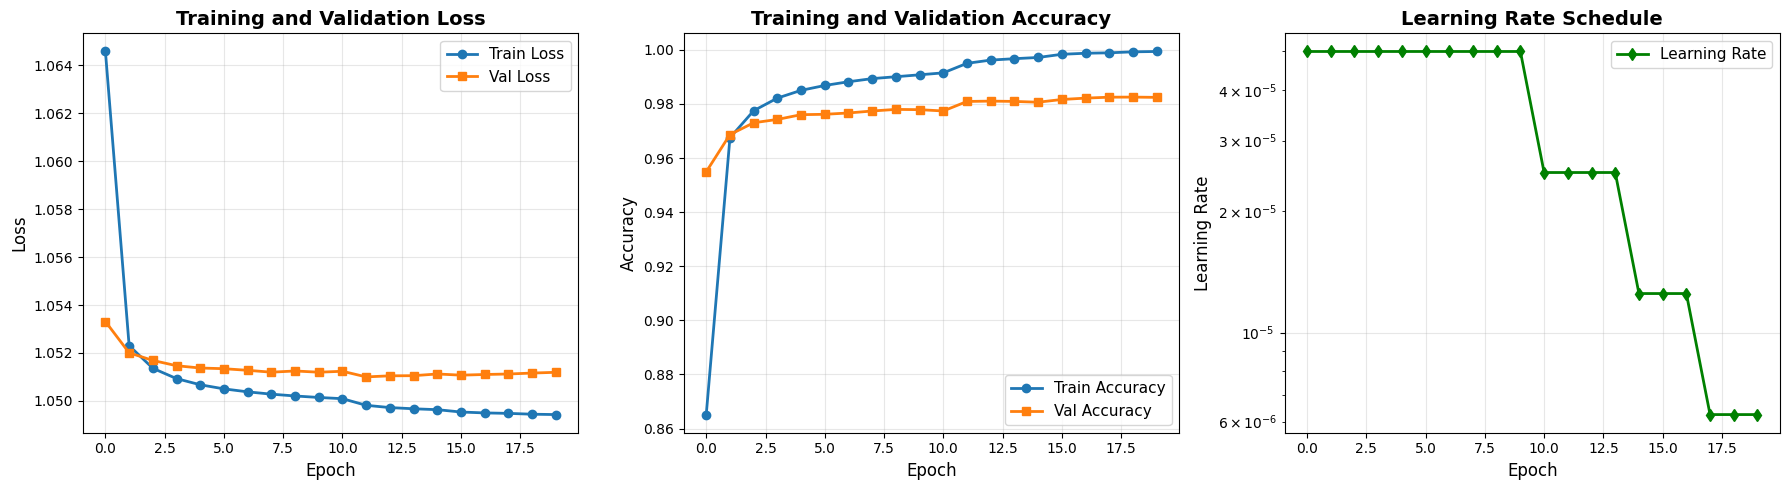


TRAINING METRICS:
Final Train Acc: 0.9994
Final Val Acc:   0.9824
Best Val Acc:    0.9825 (Epoch 19)
Final Train Loss: 1.0494
Final Val Loss:   1.0512


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Learning rate plot
axes[2].plot(history['lr'], label='Learning Rate', marker='d', linewidth=2, color='green')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Learning Rate', fontsize=12)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].set_yscale('log')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'=' * 60}")
print('TRAINING METRICS:')
print(f"{'=' * 60}")
print(f"Final Train Acc: {history['train_acc'][-1]:.4f}")
print(f"Final Val Acc:   {history['val_acc'][-1]:.4f}")
print(f"Best Val Acc:    {max(history['val_acc']):.4f} (Epoch {history['val_acc'].index(max(history['val_acc'])) + 1})")
print(f"Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Val Loss:   {history['val_loss'][-1]:.4f}")
print(f"{'=' * 60}")

In [13]:
# Load the best model from training before inference
best_model_path = os.path.join(OUTPUT_DIR, 'best_model.pt')
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"Loaded best model from: {best_model_path}")
else:
    print("Best model not found. Running inference with current model weights.")

# Handle DataParallel model for inference
inference_model = model.module if torch.cuda.device_count() > 1 else model
inference_model.eval()

# Select 100 random validation indices, evenly spread across the full validation set range
num_samples = min(100, len(val_dataset))
bin_edges = np.linspace(0, len(val_dataset), num_samples + 1, dtype=int)
selected_indices = []
for i in range(num_samples):
    start_idx = bin_edges[i]
    end_idx = bin_edges[i + 1]
    if end_idx <= start_idx:
        idx = start_idx
    else:
        idx = np.random.randint(start_idx, end_idx)
    selected_indices.append(idx)

print(f"\nInference on {num_samples} evenly distributed random validation samples:\n")
print("=" * 80)

for n, idx in enumerate(selected_indices, start=1):
    sample = val_dataset[idx]
    pixel_values = sample['pixel_values'].unsqueeze(0).to(device)

    with torch.no_grad():
        generated_ids = inference_model.generate(
            pixel_values=pixel_values,
            max_length=128,
            num_beams=5,
            bos_token_id=text_processor.bos_token_id,
            eos_token_id=text_processor.eos_token_id,
            pad_token_id=text_processor.pad_token_id
        )

    predicted_text = text_processor.decode(generated_ids[0].cpu().numpy())
    ground_truth = text_processor.decode(sample['labels'].cpu().numpy())

    match = predicted_text.strip() == ground_truth.strip()

    print(f"Sample {n} (val idx {idx}):")
    print(f"  Ground Truth: {ground_truth}")
    print(f"  Predicted:    {predicted_text}")
    print(f"  Match: {'✓' if match else '✗'}")
    print("-" * 80)

print("\nInference completed!")

Loaded best model from: /kaggle/working/best_model.pt

Inference on 100 evenly distributed random validation samples:

Sample 1 (val idx 102):
  Ground Truth: ধম
  Predicted:    ধম
  Match: ✓
--------------------------------------------------------------------------------
Sample 2 (val idx 1256):
  Ground Truth: স্প
  Predicted:    স্প
  Match: ✓
--------------------------------------------------------------------------------
Sample 3 (val idx 1913):
  Ground Truth: কোথায়
  Predicted:    শহরের
  Match: ✗
--------------------------------------------------------------------------------
Sample 4 (val idx 2571):
  Ground Truth: ণব
  Predicted:    ন্ব
  Match: ✗
--------------------------------------------------------------------------------
Sample 5 (val idx 3358):
  Ground Truth: প্ট
  Predicted:    প্ট
  Match: ✓
--------------------------------------------------------------------------------
Sample 6 (val idx 4809):
  Ground Truth: ০
  Predicted:    ০
  Match: ✓
------------------------